# Inferential Statistical Analysis

## Statistical Analysis of Waste Management Practices Among Households and Business Establishments in Sri Lanka

In this notebook, we conduct inferential statistical analysis using
the final cleaned waste management survey dataset.

We use the sample data to make statistical conclusions about the
population represented by our survey.

We use:
- One-Sample t-Tests
- One-Sample Z-Tests
- Hypothesis testing
- Test statistics
- Critical values
- P-values
- Statistical decisions and conclusions

## 1. Introduction

In our project, we collected data about waste management practices
among households and business establishments in Sri Lanka.

For the inferential analysis, we use the final cleaned dataset.

We focus mainly on waste quantities recorded using bags and bins.
These measurements were used in our questionnaire because waste
quantity was difficult to standardize using weight or volume.

We conduct one-sample hypothesis tests to examine selected
characteristics of weekly waste generation.

## 2. Import Required Libraries

We use the following Python libraries for data loading,
data processing and statistical analysis.

In [ ]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical calculations
import numpy as np

# Import scipy.stats for statistical tests
from scipy import stats

# Import matplotlib for simple visualizations
import matplotlib.pyplot as plt

## 3. Load the Final Cleaned Dataset

We use the final cleaned Excel dataset for our inferential analysis.

The dataset contains the responses retained after the data cleaning
process.

In [ ]:
# Specify the location of the final cleaned dataset
file_path = "/content/Final_Cleaned_Waste_Survey_185.xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

# Display dataset information
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display the first five rows
df.head()

Number of rows: 185
Number of columns: 49


,Q1. Age,Q2. Province,Q3. District,Q4. Local Authority,Q5. Area Type,Q6. Place Type,Q7. No. of People,Q8. Land Size,Q9. Waste Storage Method,Q10. Bag Size,...,Q16. How Recycle?,Q17. Income from Recyclables?,Q18. Monthly Income (Rs.),Q19. Distance to Collection Point,Q20. Collection Frequency,Q21. Disposal Method,Q22. Monthly Spend (Rs.),Q23. Biggest Problem,Q24. Use Mobile App?,Q25. Satisfaction
0,70 years and above,Western,Colombo (කොළඹ),Maharagama Urban Council,Urban (නාගරික),Household,5 - 6 persons,10–19 perches (250–499 m²),Waste Bags,Medium Bag,...,Hand over to recycling centers,Yes,"Rs. 5,000 and above",More than 2 km,Weekly,Municipal collection service (මහ නගර / ප්‍රාදේ...,No expenditure,Other: __________,Yes,Very Satisfied
1,50 - 59 years,Western,Gampaha (ගම්පහ),Gampaha Municipal Council,Semi-urban (අර්ධ නාගරික),Household,5 - 6 persons,10–19 perches (250–499 m²),Both Bags and Bins,Large Bag,...,Sell to collectors,Yes,Less than Rs. 500,More than 2 km,Other: __________,Municipal collection service (මහ නගර / ප්‍රාදේ...,Less than Rs. 500,Lack of recycling facilities,Yes,Very Dissatisfied
2,20 - 29 years,Western,Colombo (කොළඹ),Colombo Municipal Council,Semi-urban (අර්ධ නාගරික),Household,3 - 4 persons,Less than 10 perches (<250 m²),Waste Bins,NaN,...,Reuse at home,No,NaN,More than 2 km,Weekly,Municipal collection service (මහ නගර / ප්‍රාදේ...,No expenditure,Limited space for waste storage,Yes,Satisfied
3,20 - 29 years,Southern,Galle (ගාල්ල),Bentota Pradeshiya Sabha,Semi-urban (අර්ධ නාගරික),Household,5 - 6 persons,20–39 perches (500–999 m²),Other (Specify),Medium Bag,...,Reuse at home,Yes,Less than Rs. 500,No collection point available,Other: __________,"Composting (කොම්පෝස්ට් කිරීම), Burying (වළ දැම...","Rs. 1,000–2,999","Irregular waste collection, Lack of awareness,...",Yes,Neutral
4,20 - 29 years,Western,Kalutara (කළුතර),Madurawala Pradeshiya Sabha,Rural (ග්‍රාමීය),Household,More than 8 persons,20–39 perches (500–999 m²),Both Bags and Bins,Extra Large Bag,...,NaN,No,NaN,1–2 km,Other: __________,Burning in an open area (විවෘතව ගිනි තැබීම),No expenditure,Limited space for waste storage,Yes,Neutral


## 4. Check the Dataset

We first check the structure of our dataset before starting
the inferential analysis.

We check the variable names and data types.

In [ ]:
# Display the column names
print("Variables in the dataset:")

for column in df.columns:
    print(column)

Variables in the dataset:
Q1. Age
Q2. Province
Q3. District
Q4. Local Authority
Q5. Area Type
Q6. Place Type
Q7. No. of People
Q8. Land Size
Q9. Waste Storage Method
Q10. Bag Size
Q11. Bin Size
Q12a. Food Waste (bags)
Q12b. Garden Waste (bags)
Q12c. Plastic (bags)
Q12d. Paper (bags)
Q12e. Glass (bags)
Q12f. Metal (bags)
Q12g. E-Waste (bags)
Q12h. Textile (bags)
Q12i. Rubber (bags)
Q12j. Coconut (bags)
Q12k. Packaging (bags)
Q12l. Medical (bags)
Q12m. Other (bags)
Q13a. Food Waste (bins)
Q13b. Garden Waste (bins)
Q13c. Plastic (bins)
Q13d. Paper (bins)
Q13e. Glass (bins)
Q13f. Metal (bins)
Q13g. E-Waste (bins)
Q13h. Textile (bins)
Q13i. Rubber (bins)
Q13j. Coconut (bins)
Q13k. Packaging (bins)
Q13l. Medical (bins)
Q13m. Other (bins)
Q14. Separate Recyclables?
Q15. Recycle Waste?
Q16. How Recycle?
Q17. Income from Recyclables?
Q18. Monthly Income (Rs.)
Q19. Distance to Collection Point
Q20. Collection Frequency
Q21. Disposal Method
Q22. Monthly Spend (Rs.)
Q23. Biggest Problem
Q24. Use M

In [ ]:
# Display the data types of the variables
df.dtypes

,0
Q1. Age,object
Q2. Province,object
Q3. District,object
Q4. Local Authority,object
Q5. Area Type,object
Q6. Place Type,object
Q7. No. of People,object
Q8. Land Size,object
Q9. Waste Storage Method,object
Q10. Bag Size,object


## 5. Preparing Waste Quantity Variables

In our questionnaire, waste quantities are recorded separately
for different types of waste.

Q12 contains waste quantities measured using bags.

Q13 contains waste quantities measured using bins.

Some values are recorded as fractions such as 1/2. Therefore,
we convert these values into numerical values before calculating
the total weekly waste.

In [ ]:
# Select the waste quantity variables recorded in bags
bag_columns = [
    'Q12a. Food Waste (bags)',
    'Q12b. Garden Waste (bags)',
    'Q12c. Plastic (bags)',
    'Q12d. Paper (bags)',
    'Q12e. Glass (bags)',
    'Q12f. Metal (bags)',
    'Q12g. E-Waste (bags)',
    'Q12h. Textile (bags)',
    'Q12i. Rubber (bags)',
    'Q12j. Coconut (bags)',
    'Q12k. Packaging (bags)',
    'Q12l. Medical (bags)',
    'Q12m. Other (bags)'
]

# Select the waste quantity variables recorded in bins
bin_columns = [
    'Q13a. Food Waste (bins)',
    'Q13b. Garden Waste (bins)',
    'Q13c. Plastic (bins)',
    'Q13d. Paper (bins)',
    'Q13e. Glass (bins)',
    'Q13f. Metal (bins)',
    'Q13g. E-Waste (bins)',
    'Q13h. Textile (bins)',
    'Q13i. Rubber (bins)',
    'Q13j. Coconut (bins)',
    'Q13k. Packaging (bins)',
    'Q13l. Medical (bins)',
    'Q13m. Other (bins)'
]

### Converting Waste Quantities

Some waste quantities are stored as numbers, while some are stored
as fractions.

For example:

1/2 = 0.5

We convert these values into numerical form so that we can calculate
the total waste quantity.

In [ ]:
def convert_quantity(value):
    # Treat blank values as zero
    if pd.isna(value):
        return 0

    value = str(value).strip()

    # Convert fractions such as 1/2 into numerical values
    if "/" in value:
        try:
            numerator, denominator = value.split("/")
            return float(numerator) / float(denominator)
        except:
            return np.nan

    # Convert normal numerical values
    try:
        return float(value)
    except:
        return np.nan

In [ ]:
# Convert all bag and bin quantities into numerical values
for col in bag_columns + bin_columns:
    df[col] = df[col].apply(convert_quantity)

## 6. Calculate Total Weekly Waste Quantities

We now calculate two main numerical variables.

- Total Bags/Wk represents the total number of waste bags recorded
  for each respondent.
- Total Bins/Wk represents the total number of waste bins recorded
  for each respondent.

We calculate these values by adding the individual waste categories.

In [ ]:
# Calculate the total number of waste bags per week
df["Total Bags/Wk"] = df[bag_columns].sum(axis=1)

# Calculate the total number of waste bins per week
df["Total Bins/Wk"] = df[bin_columns].sum(axis=1)

# Display the calculated variables
df[["Total Bags/Wk", "Total Bins/Wk"]].head()

,Total Bags/Wk,Total Bins/Wk
0,2.0,0.0
1,6.0,3.0
2,0.0,2.0
3,5.5,5.0
4,7.0,5.0


In [ ]:
# Display summary information about total bags and bins
df[["Total Bags/Wk", "Total Bins/Wk"]].describe()

,Total Bags/Wk,Total Bins/Wk
count,185.000000,185.000000
mean,4.756757,4.918919
std,6.722591,7.024330
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.000000,3.500000
75%,7.000000,6.500000
max,32.000000,71.000000


## 7. Check Missing Values

Before conducting the hypothesis tests, we check whether the
calculated variables contain missing values.

In [ ]:
# Check missing values in the variables used for analysis
df[["Total Bags/Wk", "Total Bins/Wk"]].isnull().sum()

,0
Total Bags/Wk,0
Total Bins/Wk,0


# 8. Summary Statistics

We first calculate the basic summary statistics for the main
numerical variables.

We calculate the sample size, mean, median, minimum, maximum,
variance and standard deviation.

In [ ]:
# Select the main numerical variables
variables = [
    "Total Bags/Wk",
    "Total Bins/Wk"
]

summary = []

# Calculate summary statistics for each variable
for var in variables:
    data = df[var].dropna()

    summary.append({
        "Variable": var,
        "Sample Size": len(data),
        "Mean": data.mean(),
        "Median": data.median(),
        "Minimum": data.min(),
        "Maximum": data.max(),
        "Variance": data.var(),
        "Standard Deviation": data.std()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Variable,Sample Size,Mean,Median,Minimum,Maximum,Variance,Standard Deviation
0,Total Bags/Wk,185,4.756757,3.0,0.0,32.0,45.193229,6.722591
1,Total Bins/Wk,185,4.918919,3.5,0.0,71.0,49.341216,7.024330


## 9. Distribution of Weekly Waste Quantities

We use histograms to get a simple view of the distributions of
the two numerical variables used in our hypothesis tests.

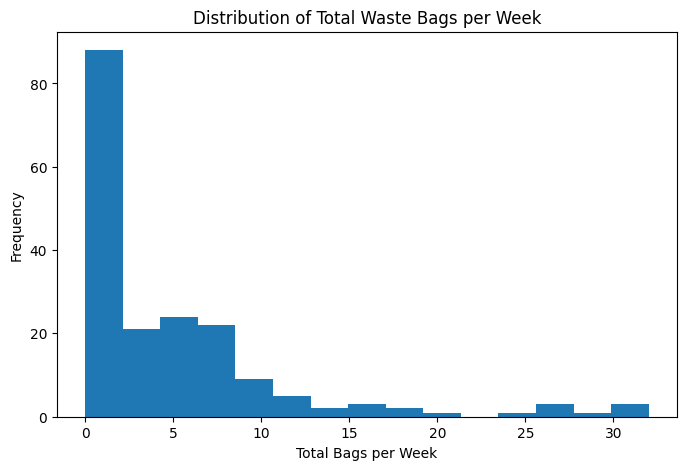

In [ ]:
# Plot the distribution of total weekly waste bags
plt.figure(figsize=(8, 5))

plt.hist(df["Total Bags/Wk"].dropna(), bins=15)

plt.xlabel("Total Bags per Week")
plt.ylabel("Frequency")
plt.title("Distribution of Total Waste Bags per Week")

plt.show()

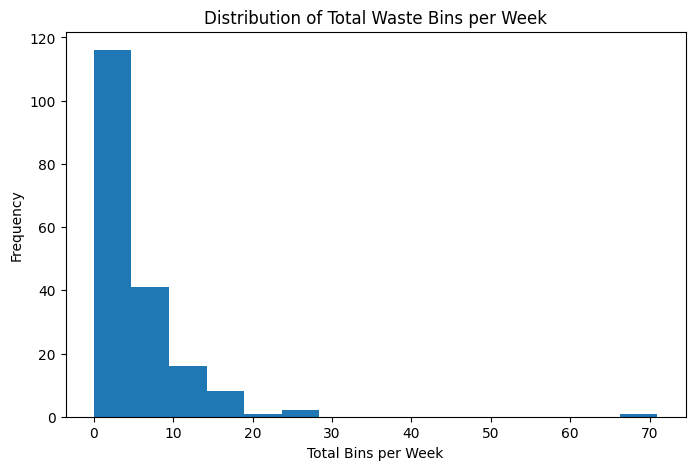

In [ ]:
# Plot the distribution of total weekly waste bins
plt.figure(figsize=(8, 5))

plt.hist(df["Total Bins/Wk"].dropna(), bins=15)

plt.xlabel("Total Bins per Week")
plt.ylabel("Frequency")
plt.title("Distribution of Total Waste Bins per Week")

plt.show()

# 10. Inferential Analysis

In this section, we conduct hypothesis tests using our sample data.

We use a significance level of:

α = 0.05

For each hypothesis test, we:

1. State the hypotheses
2. Specify the test information
3. Calculate the test statistic
4. Determine the critical value
5. Apply the decision rule
6. Give the conclusion

# 11. One-Sample t-Test – Total Waste Bags

## Research Question 1

Is the average number of waste bags generated per week greater
than 5 bags?

We use 5 bags per week as the reference value for this statistical
test.

This value is used as a reference value for hypothesis testing and
is not treated as an official waste-management standard.

### Hypotheses

H₀: μ ≤ 5 bags/week

H₁: μ > 5 bags/week

### Significance Level

α = 0.05

We use a one-sample t-test because the population standard deviation
is not independently known.

## Test Information

Test: One-Sample t-Test

Type: Right-tailed test

Significance level: α = 0.05

In [ ]:
# Select the total weekly waste bag values
data = df["Total Bags/Wk"].dropna()

# Set the reference value and significance level
reference_value = 5
alpha = 0.05

# Perform the one-sample t-test
t_stat, p_two = stats.ttest_1samp(
    data,
    popmean=reference_value
)

# Convert the two-sided p-value into a right-tailed p-value
if t_stat > 0:
    p_value = p_two / 2
else:
    p_value = 1 - (p_two / 2)

# Calculate the degrees of freedom
df_value = len(data) - 1

print("Sample size:", len(data))
print("Sample mean:", data.mean())
print("Sample standard deviation:", data.std())
print("Reference value:", reference_value)
print("Degrees of freedom:", df_value)
print("t-statistic:", t_stat)
print("p-value:", p_value)

Sample size: 185
Sample mean: 4.756756756756757
Sample standard deviation: 6.722590910849891
Reference value: 5
Degrees of freedom: 184
t-statistic: -0.4921414739192964
p-value: 0.6883970023678803


## Critical Value

For a right-tailed t-test with α = 0.05, we calculate the
critical t-value using the degrees of freedom.

The critical value is used to compare the calculated t-statistic.

In [ ]:
# Calculate the critical t-value for a right-tailed test
t_critical = stats.t.ppf(1 - alpha, df_value)

print("Critical t-value:", t_critical)

Critical t-value: 1.6531770875301313


## Decision Rule

We reject H₀ if:

t-statistic > critical t-value

Otherwise, we fail to reject H₀.

We can also use the p-value:

If p-value < 0.05 → Reject H₀

If p-value ≥ 0.05 → Fail to reject H₀

In [ ]:
# Make the statistical decision
if t_stat > t_critical:
    decision = "Reject H₀"
else:
    decision = "Fail to reject H₀"

print("Decision:", decision)

Decision: Fail to reject H₀


In [ ]:
# Display the conclusion based on the p-value
if p_value < alpha:
    print(
        "There is sufficient statistical evidence to conclude "
        "that the average number of waste bags generated per week "
        "is greater than 5 bags."
    )
else:
    print(
        "There is insufficient statistical evidence to conclude "
        "that the average number of waste bags generated per week "
        "is greater than 5 bags."
    )

There is insufficient statistical evidence to conclude that the average number of waste bags generated per week is greater than 5 bags.


# 12. One-Sample t-Test – Total Waste Bins

## Research Question 2

Is the average number of waste bins generated per week greater
than 4 bins?

We use 4 bins per week as the reference value for this test.

### Hypotheses

H₀: μ ≤ 4 bins/week

H₁: μ > 4 bins/week

### Significance Level

α = 0.05

We use a one-sample t-test because the population standard deviation
is not independently known.

In [ ]:
# Select the total weekly waste bin values
data = df["Total Bins/Wk"].dropna()

# Set the reference value and significance level
reference_value = 4
alpha = 0.05

# Perform the one-sample t-test
t_stat, p_two = stats.ttest_1samp(
    data,
    popmean=reference_value
)

# Convert the two-sided p-value into a right-tailed p-value
if t_stat > 0:
    p_value = p_two / 2
else:
    p_value = 1 - (p_two / 2)

# Calculate degrees of freedom
df_value = len(data) - 1

# Calculate the critical value
t_critical = stats.t.ppf(1 - alpha, df_value)

print("Sample size:", len(data))
print("Sample mean:", data.mean())
print("Sample standard deviation:", data.std())
print("Reference value:", reference_value)
print("Degrees of freedom:", df_value)
print("t-statistic:", t_stat)
print("Critical t-value:", t_critical)
print("p-value:", p_value)

Sample size: 185
Sample mean: 4.918918918918919
Sample standard deviation: 7.0243303037525395
Reference value: 4
Degrees of freedom: 184
t-statistic: 1.7793366819492689
Critical t-value: 1.6531770875301313
p-value: 0.03841767017725982


In [ ]:
# Make the statistical decision
if t_stat > t_critical:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Decision: Reject H₀


In [ ]:
# Display the conclusion based on the p-value
if p_value < alpha:
    print(
        "There is sufficient statistical evidence to conclude "
        "that the average number of waste bins generated per week "
        "is greater than 4 bins."
    )
else:
    print(
        "There is insufficient statistical evidence to conclude "
        "that the average number of waste bins generated per week "
        "is greater than 4 bins."
    )

There is sufficient statistical evidence to conclude that the average number of waste bins generated per week is greater than 4 bins.


# 13. One-Sample Z-Test – Total Waste Bags

For this test, we follow the method demonstrated in the example
notebook and use the sample standard deviation as the known
population standard deviation.

## Research Question 3

Is the average number of waste bags generated per week less than
10 bags?

### Hypotheses

H₀: μ ≥ 10 bags/week

H₁: μ < 10 bags/week

### Significance Level

α = 0.05

This is a left-tailed Z-test.

In [ ]:
# Select the total weekly waste bag values
data = df["Total Bags/Wk"].dropna()

# Set the reference value
mu0 = 10

# Set the significance level
alpha = 0.05

# Calculate the sample size and sample mean
n = len(data)
sample_mean = data.mean()

# Following the example methodology, we use the sample
# standard deviation as the known population standard deviation
sigma = data.std()

# Calculate the Z-statistic
z_stat = (sample_mean - mu0) / (sigma / np.sqrt(n))

# Calculate the p-value for a left-tailed test
p_value = stats.norm.cdf(z_stat)

# Calculate the critical Z-value
z_critical = stats.norm.ppf(alpha)

print("Sample size:", n)
print("Sample mean:", sample_mean)
print("Standard deviation used:", sigma)
print("Reference value:", mu0)
print("Z-statistic:", z_stat)
print("Critical Z-value:", z_critical)
print("p-value:", p_value)

Sample size: 185
Sample mean: 4.756756756756757
Standard deviation used: 6.722590910849891
Reference value: 10
Z-statistic: -10.608382882260402
Critical Z-value: -1.6448536269514729
p-value: 1.362115518513887e-26


## Decision Rule

For this left-tailed test:

If Z-statistic < critical Z-value → Reject H₀

If Z-statistic ≥ critical Z-value → Fail to reject H₀

Using the p-value:

If p-value < 0.05 → Reject H₀

If p-value ≥ 0.05 → Fail to reject H₀


In [ ]:
# Make the statistical decision
if z_stat < z_critical:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Decision: Reject H₀


In [ ]:
# Display the conclusion
if p_value < alpha:
    print(
        "There is sufficient statistical evidence to conclude "
        "that the average number of waste bags generated per week "
        "is less than 10 bags."
    )
else:
    print(
        "There is insufficient statistical evidence to conclude "
        "that the average number of waste bags generated per week "
        "is less than 10 bags."
    )

There is sufficient statistical evidence to conclude that the average number of waste bags generated per week is less than 10 bags.


# 14. One-Sample Z-Test – Total Waste Bins

For this test, we again follow the Z-test method demonstrated
in the example notebook.

## Research Question 4

Is the average number of waste bins generated per week greater
than 8 bins?

### Hypotheses

H₀: μ ≤ 8 bins/week

H₁: μ > 8 bins/week

### Significance Level

α = 0.05

This is a right-tailed Z-test.

In [ ]:
# Select the total weekly waste bin values
data = df["Total Bins/Wk"].dropna()

# Set the reference value
mu0 = 8

# Set the significance level
alpha = 0.05

# Calculate the sample size and sample mean
n = len(data)
sample_mean = data.mean()

# Use the sample standard deviation as the known
# population standard deviation, following the example
sigma = data.std()

# Calculate the Z-statistic
z_stat = (sample_mean - mu0) / (sigma / np.sqrt(n))

# Calculate the p-value for a right-tailed test
p_value = 1 - stats.norm.cdf(z_stat)

# Calculate the critical Z-value
z_critical = stats.norm.ppf(1 - alpha)

print("Sample size:", n)
print("Sample mean:", sample_mean)
print("Standard deviation used:", sigma)
print("Reference value:", mu0)
print("Z-statistic:", z_stat)
print("Critical Z-value:", z_critical)
print("p-value:", p_value)

Sample size: 185
Sample mean: 4.918918918918919
Standard deviation used: 7.0243303037525395
Reference value: 8
Z-statistic: -5.966011227712248
Critical Z-value: 1.6448536269514722
p-value: 0.9999999987843822


## Decision Rule

For this right-tailed test:

If Z-statistic > critical Z-value → Reject H₀

If Z-statistic ≤ critical Z-value → Fail to reject H₀

Using the p-value:

If p-value < 0.05 → Reject H₀

If p-value ≥ 0.05 → Fail to reject H₀

In [ ]:
# Make the statistical decision
if z_stat > z_critical:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Decision: Fail to reject H₀


In [ ]:
# Display the conclusion
if p_value < alpha:
    print(
        "There is sufficient statistical evidence to conclude "
        "that the average number of waste bins generated per week "
        "is greater than 8 bins."
    )
else:
    print(
        "There is insufficient statistical evidence to conclude "
        "that the average number of waste bins generated per week "
        "is greater than 8 bins."
    )

There is insufficient statistical evidence to conclude that the average number of waste bins generated per week is greater than 8 bins.


# 15. Summary of Hypothesis Tests

We conducted four one-sample hypothesis tests.

Two tests were conducted using the one-sample t-test and two tests
were conducted using the one-sample Z-test.

We used both left-tailed and right-tailed tests.

The significance level for all tests was 0.05.

In [ ]:
# Store the main information about our hypothesis tests
results = pd.DataFrame({
    "Test": [
        "One-Sample t-Test",
        "One-Sample t-Test",
        "One-Sample Z-Test",
        "One-Sample Z-Test"
    ],

    "Variable": [
        "Total Bags/Wk",
        "Total Bins/Wk",
        "Total Bags/Wk",
        "Total Bins/Wk"
    ],

    "Reference Value": [
        5,
        4,
        10,
        8
    ],

    "Alternative Hypothesis": [
        "μ > 5",
        "μ > 4",
        "μ < 10",
        "μ > 8"
    ],

    "Significance Level": [
        0.05,
        0.05,
        0.05,
        0.05
    ]
})

results

,Test,Variable,Reference Value,Alternative Hypothesis,Significance Level
0,One-Sample t-Test,Total Bags/Wk,5,μ > 5,0.05
1,One-Sample t-Test,Total Bins/Wk,4,μ > 4,0.05
2,One-Sample Z-Test,Total Bags/Wk,10,μ < 10,0.05
3,One-Sample Z-Test,Total Bins/Wk,8,μ > 8,0.05


In [ ]:
# Create a table to store the final results
final_results = []

# Test 1 - t-test for Total Bags/Wk
data = df["Total Bags/Wk"].dropna()
reference = 5

t_stat, p_two = stats.ttest_1samp(data, reference)

if t_stat > 0:
    p_value = p_two / 2
else:
    p_value = 1 - (p_two / 2)

t_critical = stats.t.ppf(0.95, len(data) - 1)

decision = "Reject H₀" if t_stat > t_critical else "Fail to reject H₀"

final_results.append({
    "Test": "One-Sample t-Test",
    "Variable": "Total Bags/Wk",
    "Reference": 5,
    "Test Statistic": t_stat,
    "Critical Value": t_critical,
    "P-value": p_value,
    "Decision": decision
})


# Test 2 - t-test for Total Bins/Wk
data = df["Total Bins/Wk"].dropna()
reference = 4

t_stat, p_two = stats.ttest_1samp(data, reference)

if t_stat > 0:
    p_value = p_two / 2
else:
    p_value = 1 - (p_two / 2)

t_critical = stats.t.ppf(0.95, len(data) - 1)

decision = "Reject H₀" if t_stat > t_critical else "Fail to reject H₀"

final_results.append({
    "Test": "One-Sample t-Test",
    "Variable": "Total Bins/Wk",
    "Reference": 4,
    "Test Statistic": t_stat,
    "Critical Value": t_critical,
    "P-value": p_value,
    "Decision": decision
})


# Test 3 - Z-test for Total Bags/Wk
data = df["Total Bags/Wk"].dropna()
reference = 10

n = len(data)
mean = data.mean()
sigma = data.std()

z_stat = (mean - reference) / (sigma / np.sqrt(n))
p_value = stats.norm.cdf(z_stat)

z_critical = stats.norm.ppf(0.05)

decision = "Reject H₀" if z_stat < z_critical else "Fail to reject H₀"

final_results.append({
    "Test": "One-Sample Z-Test",
    "Variable": "Total Bags/Wk",
    "Reference": 10,
    "Test Statistic": z_stat,
    "Critical Value": z_critical,
    "P-value": p_value,
    "Decision": decision
})


# Test 4 - Z-test for Total Bins/Wk
data = df["Total Bins/Wk"].dropna()
reference = 8

n = len(data)
mean = data.mean()
sigma = data.std()

z_stat = (mean - reference) / (sigma / np.sqrt(n))
p_value = 1 - stats.norm.cdf(z_stat)

z_critical = stats.norm.ppf(0.95)

decision = "Reject H₀" if z_stat > z_critical else "Fail to reject H₀"

final_results.append({
    "Test": "One-Sample Z-Test",
    "Variable": "Total Bins/Wk",
    "Reference": 8,
    "Test Statistic": z_stat,
    "Critical Value": z_critical,
    "P-value": p_value,
    "Decision": decision
})


# Convert the results into a DataFrame
final_results_df = pd.DataFrame(final_results)

final_results_df

,Test,Variable,Reference,Test Statistic,Critical Value,P-value,Decision
0,One-Sample t-Test,Total Bags/Wk,5,-0.492141,1.653177,6.883970e-01,Fail to reject H₀
1,One-Sample t-Test,Total Bins/Wk,4,1.779337,1.653177,3.841767e-02,Reject H₀
2,One-Sample Z-Test,Total Bags/Wk,10,-10.608383,-1.644854,1.362116e-26,Reject H₀
3,One-Sample Z-Test,Total Bins/Wk,8,-5.966011,1.644854,1.000000e+00,Fail to reject H₀


# 16. Overall Interpretation

We conducted four one-sample hypothesis tests using the final
cleaned dataset.

We used one-sample t-tests and one-sample Z-tests to examine
selected weekly waste-generation measures against specified
reference values.

We used a significance level of 0.05 for all tests.

The decisions were made using the calculated test statistics,
critical values and p-values.

When the p-value is less than 0.05, we reject the null hypothesis.

When the p-value is greater than or equal to 0.05, we fail to
reject the null hypothesis.

The results help us understand whether the sample provides
statistical evidence for the selected waste-generation research
questions.

# 17. Conclusion

In this analysis, we used the final cleaned waste management
survey dataset to conduct inferential statistical analysis.

We prepared numerical waste variables by converting the recorded
bag and bin quantities and calculating the total weekly quantities.

We then conducted four one-sample hypothesis tests using
one-sample t-tests and one-sample Z-tests.

We used both right-tailed and left-tailed tests with a significance
level of 0.05.

The statistical decisions were based on the test statistics,
critical values and p-values.

Overall, the analysis provides statistical evidence about the
weekly waste-generation characteristics observed in our survey
sample.